# Portfolio Allocator Comparison

**Docker image**: `ml4t`

This capstone notebook compares allocation methods on equal footing, using identical
data and backtest protocols to isolate the impact of the allocation choice.
Equal-weight and inverse-volatility baselines run against MVO and HRP on the same signals.

**Learning Objectives**:
- Run controlled comparisons of allocation methods (EW, IV, MVO, HRP)
- Interpret walk-forward backtest results with regime-sliced diagnostics
- Evaluate methods on Sharpe, drawdown, turnover, and stability
- Understand when allocation choice matters vs when signal dominates

**Book Reference**: Chapter 17, §17.4 (Baseline allocators) and §17.7 (Comparing allocator performance)

**Prerequisites**: `02_mean_variance_optimization`, `06_hierarchical_risk_parity`

## 1. Setup and Imports

In [1]:
"""Portfolio Allocator Comparison — compare MVO, HRP, risk parity, and equal weight on ETF data."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
from collections.abc import Callable

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.visualization import create_portfolio_dashboard
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from case_studies.utils.backtest_loaders import compute_allocator_metrics
from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [3]:
# Production defaults — Papermill overrides for CI testing
MAX_SYMBOLS = 0  # 0 = all
START_DATE = "2016-01-01"
END_DATE = "2024-01-01"
SEED = 42

In [4]:
set_global_seeds(SEED)

## 2. Data Acquisition

We use a diversified ETF universe spanning equities, fixed income, alternatives, and sectors.

In [5]:
# Full universe using diversified ETFs
US_EQUITIES = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY", "IWF", "IWD"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO", "IEFA", "IEMG"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "BND", "IEF", "EMB", "MBB"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC", "IAU"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY", "XLB", "XLRE"]
_FULL_UNIVERSE = [*US_EQUITIES, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

In [6]:
# Configuration
UNIVERSE = _FULL_UNIVERSE[:MAX_SYMBOLS] if MAX_SYMBOLS else _FULL_UNIVERSE
BACKTEST_START = "2018-01-01"

print(f"Loading data for {len(UNIVERSE)} ETFs...")

Loading data for 39 ETFs...


### Load ETF Price Panel

This helper enforces a consistent data source and panel shape across all allocation methods.

In [7]:
def fetch_etf_data(symbols: list[str], start: str, end: str) -> pd.DataFrame:
    """Load OHLCV data from canonical ETF dataset."""
    etf_data = load_etfs()
    etf_filtered = etf_data.filter(
        (pl.col("symbol").is_in(symbols))
        & (pl.col("timestamp") >= pl.lit(start).str.to_date())
        & (pl.col("timestamp") <= pl.lit(end).str.to_date())
    )

    close_prices = (
        etf_filtered.select(["timestamp", "symbol", "close"])
        .pivot(on="symbol", index="timestamp", values="close")
        .sort("timestamp")
        .to_pandas()
        .set_index("timestamp")
        .ffill()
        .dropna()
    )
    return close_prices


close_prices = fetch_etf_data(UNIVERSE, START_DATE, END_DATE)
returns = close_prices.pct_change().dropna()
print(f"Loaded {len(returns):,} days for {close_prices.shape[1]} ETFs")

Loaded 2,011 days for 36 ETFs


In [8]:
def select_feature_config(n_observations: int) -> dict[str, list[int] | int]:
    """Scale feature windows to the available history."""
    if n_observations >= 252:
        return {"momentum": [21, 63, 126], "moving_average": [21, 63], "volatility": 21}
    if n_observations >= 126:
        return {"momentum": [10, 21, 42], "moving_average": [10, 21], "volatility": 10}
    return {"momentum": [5, 10, 21], "moving_average": [5, 10], "volatility": 5}


FEATURE_CONFIG = select_feature_config(len(close_prices))
FEATURE_SUFFIXES = [
    *(f"_mom_{window}d" for window in FEATURE_CONFIG["momentum"]),
    *(f"_ma_dist_{window}d" for window in FEATURE_CONFIG["moving_average"]),
    f"_vol_{FEATURE_CONFIG['volatility']}d",
]
print(f"Feature windows: {FEATURE_CONFIG}")

Feature windows: {'momentum': [21, 63, 126], 'moving_average': [21, 63], 'volatility': 21}


## 3. Generate a Common ETF Signal

We use Ridge regression to predict forward returns and select the top/bottom stocks.

In [9]:
def compute_features(prices_df: pd.DataFrame) -> pd.DataFrame:
    """Compute predictive features."""
    features = pd.DataFrame(index=prices_df.index)
    momentum_windows = FEATURE_CONFIG["momentum"]
    moving_average_windows = FEATURE_CONFIG["moving_average"]
    volatility_window = FEATURE_CONFIG["volatility"]

    for symbol in prices_df.columns:
        close = prices_df[symbol]

        # Momentum
        for window in momentum_windows:
            features[f"{symbol}_mom_{window}d"] = close.pct_change(window)

        # Mean reversion
        for window in moving_average_windows:
            features[f"{symbol}_ma_dist_{window}d"] = close / close.rolling(window).mean() - 1

        # Volatility
        features[f"{symbol}_vol_{volatility_window}d"] = (
            close.pct_change().rolling(volatility_window).std()
        )

    return features.dropna()

### Ridge Signal Generation

Signals are re-estimated on each rebalance date using rolling cross-sectional samples.

#### Feature Row Helper

In [10]:
def get_feature_row(features_df, symbol, date):
    """Fetch one symbol's feature vector for a given date."""
    feature_cols = [f"{symbol}{suffix}" for suffix in FEATURE_SUFFIXES]
    if not all(col in features_df.columns for col in feature_cols):
        return None
    row = features_df.loc[date, feature_cols].values
    return row if len(row) == len(FEATURE_SUFFIXES) else None

#### Rolling Sample Builder

In [11]:
def build_training_samples(features_df, returns, symbols, dates, train_start, train_end, horizon):
    """Build cross-sectional rolling samples for one rebalance step."""
    x_train, y_train = [], []
    for t in range(train_start, train_end):
        target_date = dates[t + horizon] if t + horizon < len(dates) else None
        if target_date is None:
            continue
        for symbol in symbols:
            features = get_feature_row(features_df, symbol, dates[t])
            if features is None:
                continue
            target = returns.loc[target_date, symbol] if symbol in returns.columns else np.nan
            if not np.isnan(features).any() and not np.isnan(target):
                x_train.append(features)
                y_train.append(target)
    return np.array(x_train), np.array(y_train)

#### Cross-Section Predictor

In [12]:
def predict_cross_section(features_df, symbols, signal_date, scaler, model):
    """Generate per-symbol predictions for one signal date."""
    predictions = {}
    for symbol in symbols:
        features = get_feature_row(features_df, symbol, signal_date)
        if features is None or np.isnan(features).any():
            continue
        features_scaled = scaler.transform(features.reshape(1, -1))
        predictions[symbol] = model.predict(features_scaled)[0]
    return predictions

#### Ridge Fit Helper

In [13]:
def fit_ridge_model(x_train, y_train):
    """Fit one cross-sectional Ridge model and return scaler + model."""
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(x_train_scaled, y_train)
    return scaler, model

#### Signal Row Assembler

In [14]:
def append_signal_rows(
    all_signals, symbols, signal_date, predictions, long_stocks, short_stocks, top_n, bottom_n
):
    """Append one rebalance date's signal rows."""
    for symbol in symbols:
        weight = 0.0
        if symbol in long_stocks:
            weight = 1.0 / top_n
        elif symbol in short_stocks:
            weight = -1.0 / bottom_n
        all_signals.append(
            {
                "timestamp": signal_date,
                "symbol": symbol,
                "prediction": predictions.get(symbol, np.nan),
                "ml_signal": weight,
            }
        )

#### Rebalance Step Helper

Process one rebalance date: train model, predict, select long/short, and record signals.

In [15]:
def _process_rebalance_step(
    features_df, returns, symbols, dates, i, lookback, horizon, top_n, bottom_n, all_signals
):
    """Train, predict, and record signals for one rebalance date."""
    train_start = max(0, i - lookback)
    x_train, y_train = build_training_samples(
        features_df=features_df,
        returns=returns,
        symbols=symbols,
        dates=dates,
        train_start=train_start,
        train_end=i,
        horizon=horizon,
    )
    if len(x_train) < 100:
        return
    scaler, model = fit_ridge_model(x_train, y_train)
    predictions = predict_cross_section(features_df, symbols, dates[i], scaler, model)
    effective_n = min(top_n, bottom_n, max(1, len(predictions) // 2))
    if effective_n == 0:
        return
    pred_series = pd.Series(predictions).sort_values(ascending=False)
    append_signal_rows(
        all_signals,
        symbols,
        dates[i],
        predictions,
        pred_series.head(effective_n).index.tolist(),
        pred_series.tail(effective_n).index.tolist(),
        effective_n,
        effective_n,
    )

#### Walk-Forward Signal Loop

In [16]:
def generate_ml_signals(
    prices: pd.DataFrame,
    lookback: int = 252,
    horizon: int = 5,
    top_n: int = 10,
    bottom_n: int = 10,
    rebalance_freq: int = 21,
) -> pd.DataFrame:
    """Generate long/short signal weights using walk-forward Ridge regression."""
    returns = prices.pct_change()
    symbols = prices.columns.tolist()
    features_df = compute_features(prices)
    all_signals = []
    dates = features_df.index.tolist()

    for i in range(lookback, len(dates) - horizon, rebalance_freq):
        if dates[i] < pd.Timestamp(BACKTEST_START):
            continue
        _process_rebalance_step(
            features_df,
            returns,
            symbols,
            dates,
            i,
            lookback,
            horizon,
            top_n,
            bottom_n,
            all_signals,
        )
    return pd.DataFrame(all_signals)

In [17]:
print("Generating ML signals (this may take a minute)...")
if len(close_prices) >= 504:
    LOOKBACK, REBALANCE_FREQ, TOP_N, BOTTOM_N = 252, 21, 10, 10
elif len(close_prices) >= 180:
    LOOKBACK, REBALANCE_FREQ, TOP_N, BOTTOM_N = 126, 10, 5, 5
else:
    LOOKBACK, REBALANCE_FREQ, TOP_N, BOTTOM_N = 42, 5, 3, 3

max_side = max(1, close_prices.shape[1] // 4)
TOP_N = min(TOP_N, max_side)
BOTTOM_N = min(BOTTOM_N, max_side)

print(
    "Signal config:",
    {
        "lookback": LOOKBACK,
        "rebalance_freq": REBALANCE_FREQ,
        "top_n": TOP_N,
        "bottom_n": BOTTOM_N,
    },
)

ml_signals = generate_ml_signals(
    close_prices, lookback=LOOKBACK, top_n=TOP_N, bottom_n=BOTTOM_N, rebalance_freq=REBALANCE_FREQ
)
print(f"Generated {len(ml_signals):,} signal records")

if len(ml_signals) == 0:
    raise ValueError(
        "No ML signals generated from the available ETF panel.\n"
        f"Observations: {len(close_prices)}, assets: {close_prices.shape[1]}, "
        f"feature windows: {FEATURE_CONFIG}, lookback: {LOOKBACK}.\n"
        "This notebook requires enough history to estimate features and fit the walk-forward "
        "cross-sectional ridge model."
    )

# Pivot to wide format
if len(ml_signals) > 0:
    signal_dates = ml_signals["timestamp"].unique()
    print(f"Signal dates: {len(signal_dates)}")
else:
    signal_dates = []
    print("[TEST] No signal dates available")

Generating ML signals (this may take a minute)...
Signal config: {'lookback': 252, 'rebalance_freq': 21, 'top_n': 9, 'bottom_n': 9}


Generated 2,592 signal records
Signal dates: 72


## 4. Portfolio Allocation Methods

### Equal Weight

In [18]:
def equal_weight_allocation(selected: list[str], n_assets: int) -> dict[str, float]:
    """Equal weight among selected assets."""
    weight = 1.0 / len(selected) if selected else 0.0
    return dict.fromkeys(selected, weight)

### Inverse Volatility

In [19]:
def inverse_vol_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 63,
) -> dict[str, float]:
    """Inverse volatility weighting."""
    vols = returns[selected].iloc[-window:].std()
    inv_vols = 1 / vols
    inv_vols = inv_vols.replace([np.inf, -np.inf], 0).fillna(0)
    total = inv_vols.sum()
    if total > 0:
        weights = inv_vols / total
    else:
        weights = pd.Series(1 / len(selected), index=selected)
    return weights.to_dict()

### Minimum-Variance (Ledoit-Wolf)

In [20]:
def mvo_lw_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 252,
) -> dict[str, float]:
    """Minimum variance with Ledoit-Wolf shrinkage."""
    subset_returns = returns[selected].iloc[-window:].dropna(axis=1, how="any")

    if len(subset_returns.columns) < 2:
        return equal_weight_allocation(selected, len(selected))

    # Fit Ledoit-Wolf
    lw = LedoitWolf().fit(subset_returns)
    cov_shrunk = lw.covariance_

    # Minimum variance
    try:
        cov_inv = np.linalg.inv(cov_shrunk)
        ones = np.ones(len(subset_returns.columns))
        weights = cov_inv @ ones
        weights = weights / weights.sum()
        weights = np.clip(weights, 0, None)  # Long-only
        weights = weights / weights.sum()  # Renormalize
        return dict(zip(subset_returns.columns, weights, strict=False))
    except np.linalg.LinAlgError:
        return equal_weight_allocation(selected, len(selected))

### Hierarchical Risk Parity (HRP)

HRP uses hierarchical clustering on the correlation matrix to group similar assets,
then allocates via recursive bisection. We split the implementation into a cluster
variance helper and the main allocation function.

In [21]:
def _cluster_variance(cov: np.ndarray, indices: list[int]) -> float:
    """Inverse-variance-weighted portfolio variance for a cluster of assets."""
    if len(indices) == 1:
        return cov[indices[0], indices[0]]
    c = cov[np.ix_(indices, indices)]
    ivp = 1 / np.diag(c)
    ivp /= ivp.sum()
    return np.dot(ivp, np.dot(c, ivp))

#### Recursive Bisection Helper

In [22]:
def _recursive_bisect(cov: np.ndarray, sorted_idx: list[int]) -> np.ndarray:
    """Allocate weights via recursive bisection on clustered covariance matrix."""
    n = len(sorted_idx)
    weights = np.ones(n)
    clusters = [sorted_idx]
    while clusters:
        new_clusters = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue
            mid = len(cluster) // 2
            left, right = cluster[:mid], cluster[mid:]
            left_var = _cluster_variance(cov, left)
            right_var = _cluster_variance(cov, right)
            alpha = 1 - left_var / (left_var + right_var) if (left_var + right_var) > 0 else 0.5
            for i in left:
                weights[sorted_idx.index(i)] *= alpha
            for i in right:
                weights[sorted_idx.index(i)] *= 1 - alpha
            if len(left) > 1:
                new_clusters.append(left)
            if len(right) > 1:
                new_clusters.append(right)
        clusters = new_clusters
    final_weights = np.zeros(n)
    for i, orig_idx in enumerate(sorted_idx):
        final_weights[orig_idx] = weights[i]
    return final_weights / final_weights.sum()

#### HRP Allocation Function

In [23]:
def hrp_allocation(
    returns: pd.DataFrame,
    selected: list[str],
    window: int = 252,
) -> dict[str, float]:
    """Hierarchical Risk Parity allocation."""
    subset_returns = returns[selected].iloc[-window:].dropna(axis=1, how="any")
    if len(subset_returns.columns) < 2:
        return equal_weight_allocation(selected, len(selected))

    # Correlation distance and clustering
    corr = subset_returns.corr().values
    dist = np.sqrt(0.5 * (1 - corr))
    link = linkage(squareform(dist, checks=False), method="ward")
    sorted_idx = list(leaves_list(link))

    # Recursive bisection
    cov = subset_returns.cov().values
    final_weights = _recursive_bisect(cov, sorted_idx)
    return dict(zip(subset_returns.columns, final_weights, strict=False))

## 5. Backtest Engine

### Backtest Result Container

Each backtest returns a plain dict with returns, dates, cumulative return,
turnover, positions, and a `metrics` sub-dict. Annualization assumes 252
trading days per year.

### Walk-Forward Backtest Helpers

Each method receives the same signal schedule and return panel so performance differences
can be attributed to allocation, not data leakage or execution timing.

In [24]:
def _compute_signal_weights(
    signals_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    signal_date,
    allocation_fn: Callable,
    window: int,
) -> dict[str, float]:
    """Compute combined long/short weights for one signal date."""
    date_signals = signals_df[signals_df["timestamp"] == signal_date]
    long_stocks = date_signals[date_signals["ml_signal"] > 0]["symbol"].tolist()
    short_stocks = date_signals[date_signals["ml_signal"] < 0]["symbol"].tolist()
    available_returns = returns_df.loc[:signal_date]

    long_weights = allocation_fn(available_returns, long_stocks, window) if long_stocks else {}
    if short_stocks:
        short_weights = allocation_fn(available_returns, short_stocks, window)
        short_weights = {k: -v for k, v in short_weights.items()}
    else:
        short_weights = {}
    return {**long_weights, **short_weights}

#### Result Packaging Helper

Convert walk-forward positions into the weight panel and summary metrics used
throughout the controlled comparison.

In [25]:
def _build_backtest_result(
    dates_list: list[pd.Timestamp],
    portfolio_returns: list[float],
    turnover_list: list[float],
    positions_list: list[dict[str, float]],
) -> dict:
    """Package returns, positions, and metrics into a dict."""
    returns_arr = np.asarray(portfolio_returns, dtype=float)
    weight_rows = []
    for dt, pos in zip(dates_list, positions_list, strict=False):
        for asset, weight in pos.items():
            if weight != 0.0:
                weight_rows.append({"timestamp": dt, "symbol": asset, "weight": float(weight)})
    weights_df = pl.DataFrame(weight_rows) if weight_rows else None
    metrics = compute_allocator_metrics(
        pl.Series("returns", returns_arr),
        weights_df=weights_df,
        ann_factor=np.sqrt(252),
    )
    annual_vol = float(np.std(returns_arr, ddof=1) * np.sqrt(252)) if len(returns_arr) > 1 else 0.0
    return {
        "dates": dates_list,
        "returns": returns_arr,
        "cumulative_return": np.cumprod(1 + returns_arr),
        "turnover": np.asarray(turnover_list, dtype=float),
        "positions": positions_list,
        "metrics": metrics,
        "annual_vol": annual_vol,
    }

#### Backtest Loop

In [26]:
def run_backtest(
    returns_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    allocation_fn: Callable,
    allocation_name: str,
    window: int = 252,
) -> dict:
    """Run walk-forward backtest for one allocation method."""
    signal_dates = sorted(signals_df["timestamp"].unique())
    portfolio_returns, turnover_list, positions_list, dates_list = [], [], [], []
    prev_weights: dict[str, float] = {}

    for i, signal_date in enumerate(signal_dates[:-1]):
        weights = _compute_signal_weights(
            signals_df, returns_df, signal_date, allocation_fn, window
        )
        date_mask = (returns_df.index > signal_date) & (returns_df.index <= signal_dates[i + 1])
        period_dates = returns_df.index[date_mask]
        for date in period_dates:
            daily_return = sum(
                weights.get(s, 0) * returns_df.loc[date, s]
                for s in returns_df.columns
                if s in weights and not np.isnan(returns_df.loc[date, s])
            )
            portfolio_returns.append(daily_return)
            dates_list.append(date)
            positions_list.append(weights.copy())

        all_syms = set(weights) | set(prev_weights)
        turn = sum(abs(weights.get(s, 0) - prev_weights.get(s, 0)) for s in all_syms) / 2
        turnover_list.extend(
            [turn / len(period_dates)] * len(period_dates) if len(period_dates) > 0 else [0]
        )
        prev_weights = weights

    return _build_backtest_result(
        dates_list,
        portfolio_returns,
        turnover_list,
        positions_list,
    )

## 6. Run the Allocator Comparison

In [27]:
# Define allocation methods
allocation_methods = {
    "Equal Weight": lambda ret, sel, win: equal_weight_allocation(sel, len(sel)),
    "Inverse Volatility": inverse_vol_allocation,
    "MVO (Ledoit-Wolf)": mvo_lw_allocation,
    "HRP": hrp_allocation,
}

# Run backtests
print("Running portfolio allocation controlled comparison...")
results = {}

for name, fn in allocation_methods.items():
    print(f"  {name}...")
    results[name] = run_backtest(returns, ml_signals, fn, name)

print("Done!")

portfolio_analyses = {
    name: PortfolioAnalysis(returns=result["returns"], dates=result["dates"], periods_per_year=252)
    for name, result in results.items()
}

Running portfolio allocation controlled comparison...
  Equal Weight...


  Inverse Volatility...


  MVO (Ledoit-Wolf)...


  HRP...


Done!


## 7. Performance Comparison

In [28]:
# Build comparison table
comparison_data = []

for name, result in results.items():
    metrics = result["metrics"]
    comparison_data.append(
        {
            "Method": name,
            "Total Return": metrics.get("total_return", 0.0),
            "Annual Return": metrics.get("annual_return", 0.0),
            "Annual Vol": result["annual_vol"],
            "Sharpe Ratio": metrics.get("sharpe", 0.0),
            "Max Drawdown": metrics.get("max_drawdown", 0.0),
            "Calmar Ratio": metrics.get("calmar", 0.0),
            "Avg Turnover": metrics.get("avg_turnover", 0.0),
        }
    )

comparison_df = pd.DataFrame(comparison_data).sort_values("Sharpe Ratio", ascending=False)

comparison_df

,Method,Total Return,Annual Return,Annual Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio,Avg Turnover
2,MVO (Ledoit-Wolf),0.466335,0.066831,0.179643,0.4497,-0.217232,0.3076,0.104568
1,Inverse Volatility,0.476130,0.068032,0.191959,0.4386,-0.232577,0.2925,0.082822
3,HRP,0.420624,0.061136,0.192875,0.4038,-0.255840,0.2390,0.100728
0,Equal Weight,0.303016,0.045751,0.194704,0.3268,-0.196633,0.2327,0.068112


**Finding**: Ranking by Sharpe, drawdown, and turnover together prevents over-selecting methods
that win on return but fail on implementation cost or risk stability.

In [29]:
# Same numbers, formatted for readability
comparison_df.style.format(
    {
        "Total Return": "{:.1%}",
        "Annual Return": "{:.1%}",
        "Annual Vol": "{:.1%}",
        "Sharpe Ratio": "{:.3f}",
        "Max Drawdown": "{:.1%}",
        "Calmar Ratio": "{:.3f}",
        "Avg Turnover": "{:.1%}",
    }
).hide(axis="index")

Method,Total Return,Annual Return,Annual Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio,Avg Turnover
MVO (Ledoit-Wolf),46.6%,6.7%,18.0%,0.450,-21.7%,0.308,10.5%
Inverse Volatility,47.6%,6.8%,19.2%,0.439,-23.3%,0.292,8.3%
HRP,42.1%,6.1%,19.3%,0.404,-25.6%,0.239,10.1%
Equal Weight,30.3%,4.6%,19.5%,0.327,-19.7%,0.233,6.8%


**Trading implication**: If a method only marginally improves Sharpe but materially increases
turnover, the live edge is likely negative after costs.

### Practitioner Interpretation

Across the four allocators in this run, the spread in annualized return is smaller than
the spread in drawdown and turnover, so risk shape and trading cost drive the comparison
more than headline return. Read the table alongside Sharpe SEs of roughly ±0.1–0.2 on
samples of this length, treating equal weight as the default until another method shows a
net improvement on both Sharpe and turnover.

## 8. Equity Curves

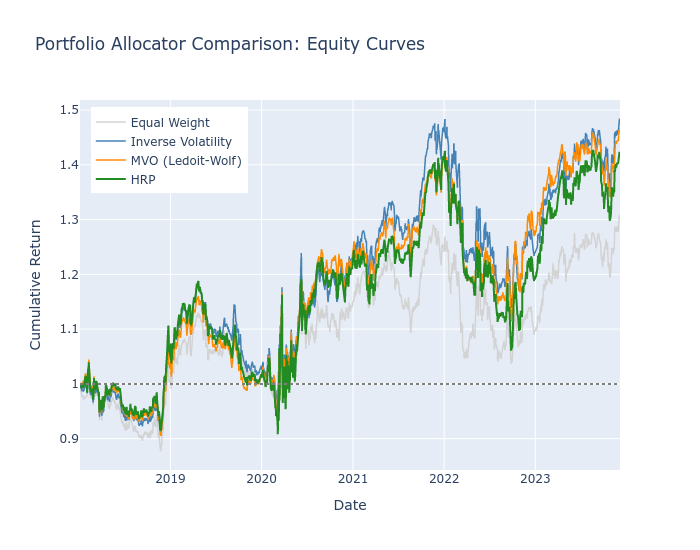

In [30]:
fig = go.Figure()

colors = {
    "Equal Weight": "lightgray",
    "Inverse Volatility": "steelblue",
    "MVO (Ledoit-Wolf)": "darkorange",
    "HRP": "forestgreen",
}

for name, result in results.items():
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=result["cumulative_return"],
            mode="lines",
            name=name,
            line=dict(color=colors.get(name, "gray"), width=2 if name == "HRP" else 1.5),
        )
    )

fig.add_hline(y=1.0, line_dash="dot", line_color="gray")

fig.update_layout(
    title="Portfolio Allocator Comparison: Equity Curves",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=550,
    legend=dict(x=0.02, y=0.98),
)
fig.show()

**Finding**: Sustained curve separation, not short-lived spikes, is the evidence that one
allocator is adding value beyond noise in the shared signal.

## 9. Drawdown Analysis

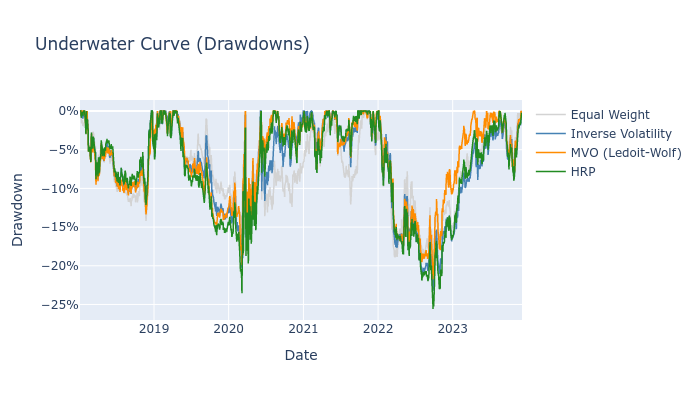

In [31]:
fig = go.Figure()

for name, result in results.items():
    dd = portfolio_analyses[name].compute_drawdown_analysis()
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=dd.underwater_curve.to_numpy(),
            mode="lines",
            name=name,
            line=dict(color=colors.get(name, "gray"), width=1.5),
        )
    )

fig.update_layout(
    title="Underwater Curve (Drawdowns)",
    xaxis_title="Date",
    yaxis_title="Drawdown",
    height=400,
    yaxis_tickformat=".0%",
)
fig.show()

**Trading implication**: Lower and shallower drawdowns can dominate small Sharpe differences
when capital constraints are driven by investor risk tolerance.

## 10. Rolling Sharpe Ratio

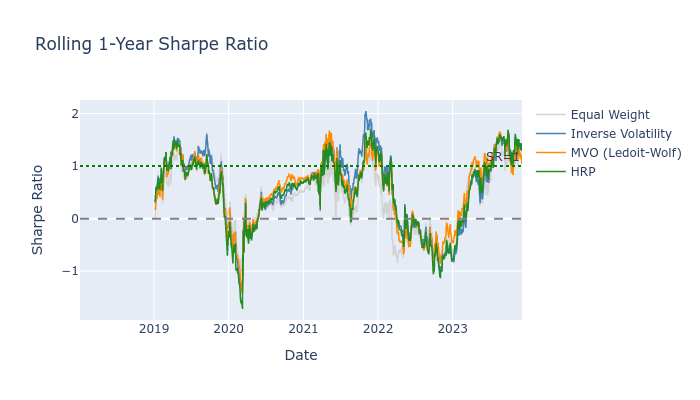

In [32]:
fig = go.Figure()

for name, result in results.items():
    rolling = portfolio_analyses[name].compute_rolling_metrics(
        windows=[252],
        metrics=["sharpe"],
    )
    rs_raw = np.asarray(rolling.sharpe[252].to_list(), dtype=float)
    rs = np.concatenate(([np.nan], rs_raw[:-1])) if rs_raw.size else rs_raw
    fig.add_trace(
        go.Scatter(
            x=result["dates"],
            y=rs,
            mode="lines",
            name=name,
            line=dict(color=colors.get(name, "gray"), width=1.5),
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.add_hline(y=1, line_dash="dot", line_color="green", annotation_text="SR=1")

fig.update_layout(
    title="Rolling 1-Year Sharpe Ratio",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    height=400,
)
fig.show()

**Finding**: Rolling Sharpe stability indicates whether a method's edge is persistent enough
to survive regime changes and operational friction.

The Sharpe ratio confidence interval under i.i.d. returns is approximately:

$$\hat{SR} \pm z_{\alpha/2} \cdot \sqrt{\frac{1 + \frac{\hat{SR}^2}{2}}{T}}$$

where $T$ is the number of observations and $z_{\alpha/2}$ is the critical value.
Overlapping confidence intervals between methods indicate that observed Sharpe differences
may not be statistically significant, reinforcing the case for simpler allocators.

## 11. Relative Performance

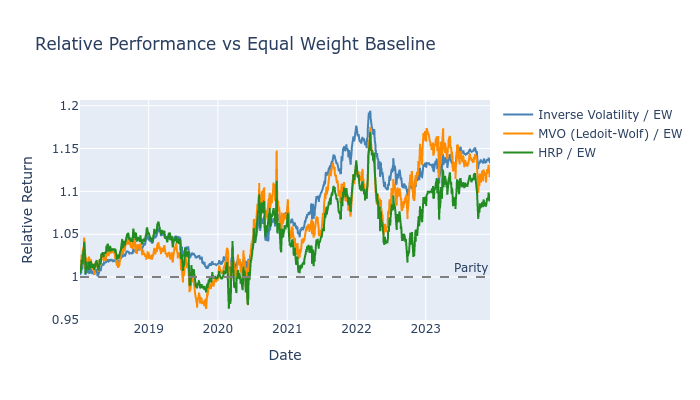

In [33]:
# Compute relative performance vs Equal Weight baseline
baseline_cum = results["Equal Weight"]["cumulative_return"]

fig = go.Figure()

for name, result in results.items():
    if name == "Equal Weight":
        continue

    # Align lengths
    min_len = min(len(result["cumulative_return"]), len(baseline_cum))
    relative = result["cumulative_return"][:min_len] / baseline_cum[:min_len]

    fig.add_trace(
        go.Scatter(
            x=result["dates"][:min_len],
            y=relative,
            mode="lines",
            name=f"{name} / EW",
            line=dict(color=colors.get(name, "gray"), width=2),
        )
    )

fig.add_hline(y=1.0, line_dash="dash", line_color="gray", annotation_text="Parity")

fig.update_layout(
    title="Relative Performance vs Equal Weight Baseline",
    xaxis_title="Date",
    yaxis_title="Relative Return",
    height=400,
)
fig.show()

**Trading implication**: Relative-performance drift below parity suggests keeping equal-weight
as the default fallback when optimization confidence degrades.

## 12. Reading the Comparison Table

We sort the allocators by Sharpe and report the magnitude of the gap to the next
method, including the gap to the equal-weight benchmark. Sharpe rankings of
allocators on a single horizon often sit within plausible measurement error;
the size of the gap is the question, not which row is on top.

In [34]:
top = comparison_df.iloc[0]
runner_up = comparison_df.iloc[1] if len(comparison_df) > 1 else None

print("\n" + "=" * 60)
print("ALLOCATOR COMPARISON — TOP-ROW READING")
print("=" * 60)
print(f"\n  Top row (by Sharpe): {top['Method']}")
print(f"  Sharpe Ratio:   {top['Sharpe Ratio']:.3f}")
print(f"  Annual Return:  {top['Annual Return']:.1%}")
print(f"  Max Drawdown:   {top['Max Drawdown']:.1%}")

if runner_up is not None:
    sharpe_gap = top["Sharpe Ratio"] - runner_up["Sharpe Ratio"]
    print(f"\n  Next in list:    {runner_up['Method']}")
    print(f"  Sharpe gap to next: {sharpe_gap:+.3f}")

print("\n" + "-" * 60)

# Gap to equal-weight benchmark
equal_sharpe = float(results["Equal Weight"]["metrics"].get("sharpe", 0.0))
top_sharpe = top["Sharpe Ratio"]
gap_vs_ew = top_sharpe - equal_sharpe

print(f"\n  Gap vs equal weight: {gap_vs_ew:+.3f} (Sharpe units)")
print("  Single-metric Sharpe gaps on samples of this length carry SEs")
print("  on the order of ±0.1–0.2; interpret alongside vol, MaxDD, and turnover.")

print("\n" + "=" * 60)


ALLOCATOR COMPARISON — TOP-ROW READING

  Top row (by Sharpe): MVO (Ledoit-Wolf)
  Sharpe Ratio:   0.450
  Annual Return:  6.7%
  Max Drawdown:   -21.7%

  Next in list:    Inverse Volatility
  Sharpe gap to next: +0.011

------------------------------------------------------------

  Gap vs equal weight: +0.123 (Sharpe units)
  Single-metric Sharpe gaps on samples of this length carry SEs
  on the order of ±0.1–0.2; interpret alongside vol, MaxDD, and turnover.



## Conclusion

Under identical ML signals, allocator choice changes risk shape and turnover more consistently
than it changes headline return, so method selection should prioritize robustness.

## Summary

The controlled comparison shows that robust, low-turnover allocators often deliver the best risk-adjusted
outcomes once implementation frictions are considered.

## Key Takeaways

### Allocator Comparison Results:

1. **Same signals, different outcomes**: The allocation method significantly impacts
   final performance, even with identical trading signals.

2. **Complexity tradeoffs**: HRP and MVO-LW estimate covariance structure; the
   estimation error competes with the signal advantage over equal-weight and inverse
   volatility, which is why the ordering across allocators depends on the universe
   and sample.

3. **Turnover matters**: Higher-turnover methods incur more transaction costs in live trading.

4. **Regime dependency**: The relative performance of methods varies across market regimes.

### Practical Recommendations:

- **Start simple**: Equal weight or inverse volatility are strong baselines
- **Test multiple methods**: No single allocation dominates all market conditions
- **Consider turnover**: Account for transaction costs when comparing methods
- **Monitor regime**: Switch allocation methods based on market conditions

### What's Next (Chapter 19):

Historical backtests measure realized risk and return but do not characterize forward
risk under regime change. Chapter 19 covers **forward-looking risk analysis**: VaR,
CVaR, stress testing, and factor attribution.

In [35]:
# Final summary table — sorted by Sharpe, key metrics only
final_summary = (
    comparison_df[["Method", "Sharpe Ratio", "Annual Return", "Max Drawdown"]]
    .reset_index(drop=True)
    .rename_axis("Rank")
)
final_summary.index = final_summary.index + 1
final_summary.style.format(
    {"Sharpe Ratio": "{:.3f}", "Annual Return": "{:.1%}", "Max Drawdown": "{:.1%}"}
)

,Method,Sharpe Ratio,Annual Return,Max Drawdown
Rank,,,,
1,MVO (Ledoit-Wolf),0.450,6.7%,-21.7%
2,Inverse Volatility,0.439,6.8%,-23.3%
3,HRP,0.404,6.1%,-25.6%
4,Equal Weight,0.327,4.6%,-19.7%


## 13. Tear Sheet for the Top Allocator — `ml4t-diagnostic`

`ml4t-diagnostic` packages the metrics + plots above into a reusable tear
sheet. We build it on whichever allocator currently ranks first by Sharpe
in the comparison table (resolved at runtime, not hard-coded), with SPY as
the benchmark so the
alpha/beta/IR readouts have meaning.

The same `PortfolioTearSheet` object supports two delivery modes:

- **Inline** — `tear_sheet.show()` renders the metrics block plus each Plotly
  figure as standard cell outputs, useful for interactive analysis.
- **HTML** — `tear_sheet.save_html(path)` writes a self-contained file for
  sharing or archival; the same content, packaged for distribution.

Tear sheet generated for: MVO (Ledoit-Wolf) (highest Sharpe in this comparison)


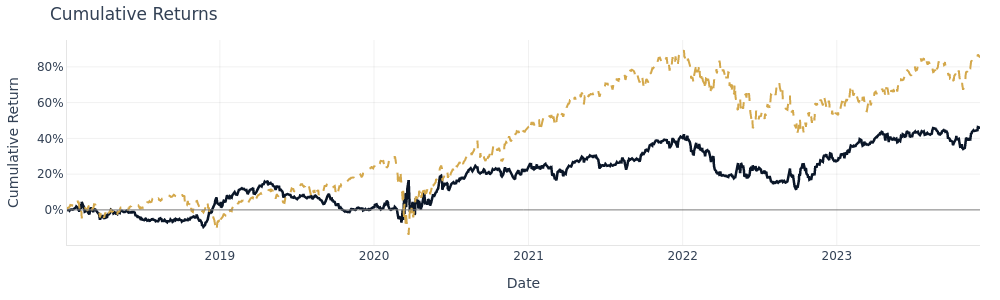

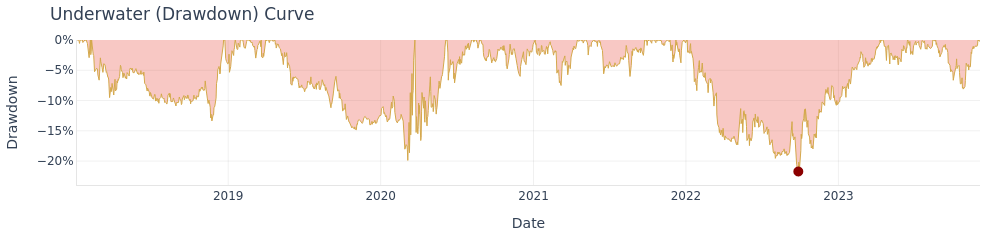

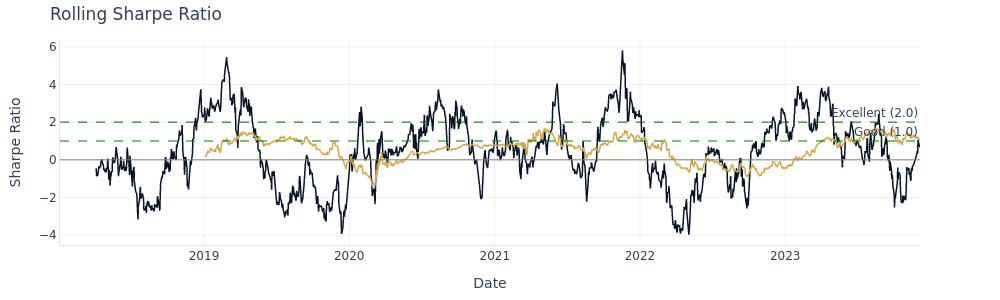

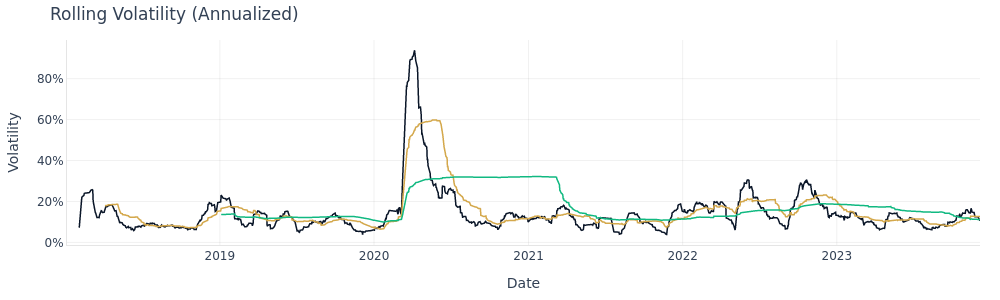

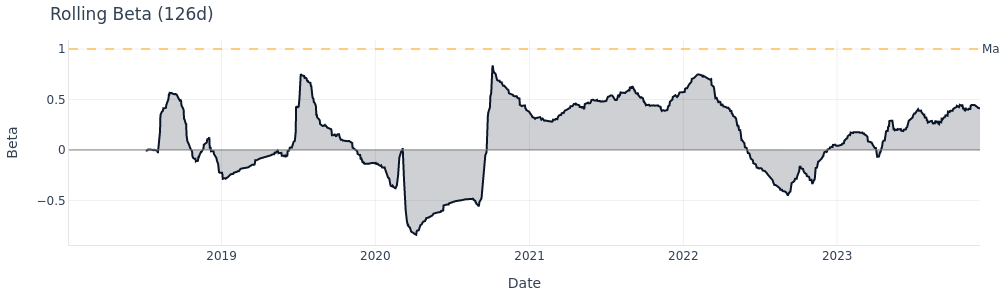

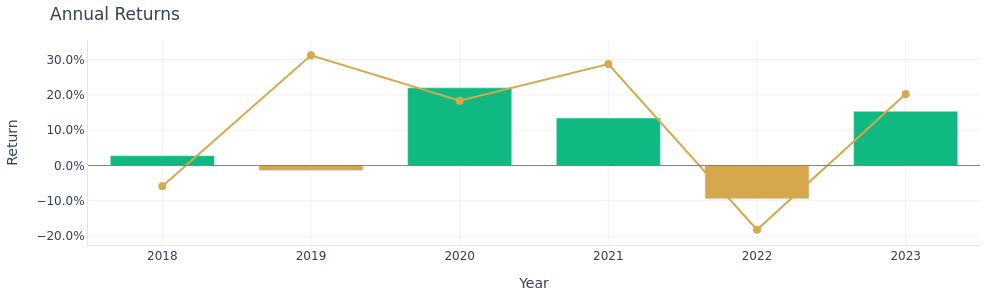

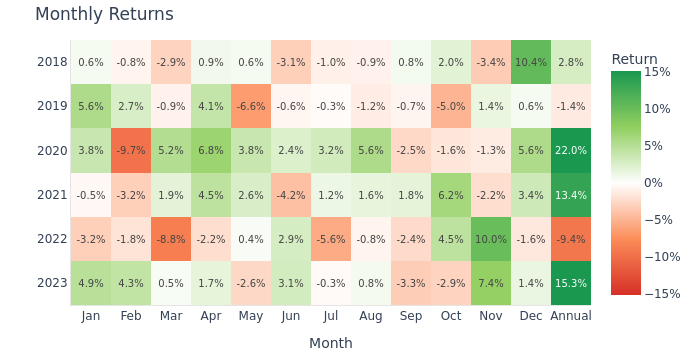

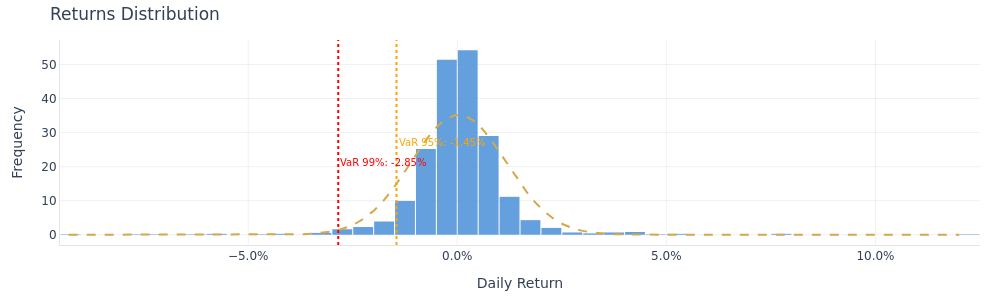

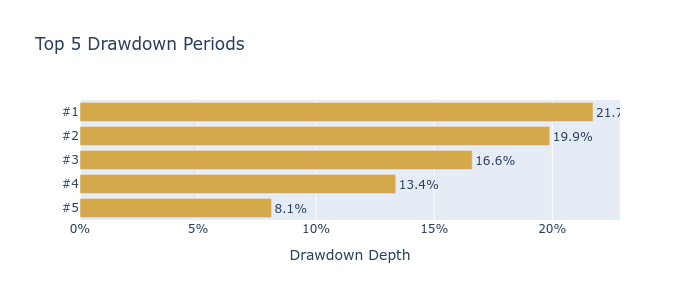

In [36]:
top_method = comparison_df.iloc[0]["Method"]
top_result = results[top_method]

# Align SPY benchmark to the top allocator's date index
spy_aligned = (
    pd.Series(returns["SPY"].values, index=returns.index)
    .reindex(pd.to_datetime(top_result["dates"]))
    .dropna()
)
common_dates = pd.Index(top_result["dates"]).intersection(spy_aligned.index)
top_returns_aligned = pd.Series(top_result["returns"], index=top_result["dates"]).loc[common_dates]
spy_aligned = spy_aligned.loc[common_dates]

top_analysis = PortfolioAnalysis(
    returns=top_returns_aligned.to_numpy(),
    benchmark=spy_aligned.to_numpy(),
    dates=common_dates,
    risk_free=0.0,
    periods_per_year=252,
)

top_tear_sheet = create_portfolio_dashboard(top_analysis)

print(f"Tear sheet generated for: {top_method} (highest Sharpe in this comparison)")

# Inline display: metrics summary + each constituent figure as a separate cell.
top_tear_sheet.show()

In [37]:
# HTML delivery: same content packaged as a self-contained file.
output_dir = get_output_dir(17, "allocator_comparison")
output_dir.mkdir(parents=True, exist_ok=True)
top_html_path = (
    output_dir
    / f"allocator_comparison_{top_method.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')}_tear_sheet.html"
)
top_tear_sheet.save_html(top_html_path, include_plotlyjs="cdn")
print(f"Top allocator tear sheet saved: {top_html_path}")
print(f"  Figures embedded: {list(top_tear_sheet.figures.keys())}")

Top allocator tear sheet saved: 17_portfolio_construction/output/allocator_comparison/allocator_comparison_mvo_ledoit_wolf_tear_sheet.html
  Figures embedded: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


## 14. Production Backtesting with ml4t-backtest

The weight-based comparison above is ideal for **method selection** - it isolates
the impact of allocation choices from execution effects. For **production backtesting**
with realistic fills, commissions, and slippage, use ml4t-backtest.

This section runs the highest-Sharpe allocation method from the comparison through
ml4t-backtest with execution simulation.

### Strategy Wrapper for ml4t-backtest

This class adapts the winning allocator to the engine API for realistic execution simulation.

In [38]:
def compute_target_weights(
    date_signals: pd.DataFrame,
    available_returns: pd.DataFrame,
    allocation_fn: Callable,
    allocation_name: str,
) -> dict[str, float]:
    """Build long/short target weights for one rebalance date."""
    target_weights: dict[str, float] = {}
    long_stocks = date_signals[date_signals["ml_signal"] > 0]["symbol"].tolist()
    short_stocks = date_signals[date_signals["ml_signal"] < 0]["symbol"].tolist()

    if long_stocks:
        if allocation_name == "Equal Weight":
            long_weights = equal_weight_allocation(long_stocks, len(long_stocks))
        else:
            long_weights = allocation_fn(available_returns, long_stocks, 63)
        target_weights.update(long_weights)

    if short_stocks:
        if allocation_name == "Equal Weight":
            short_weights = equal_weight_allocation(short_stocks, len(short_stocks))
        else:
            short_weights = allocation_fn(available_returns, short_stocks, 63)
        target_weights.update({k: -v for k, v in short_weights.items()})
    return target_weights

#### Engine Strategy Class

In [39]:
class AllocatorComparisonStrategy(Strategy):
    """Apply comparison allocations through ml4t-backtest execution."""

    def __init__(self, assets, signals_df, allocation_fn, allocation_name, returns_df):
        self.signals_df = signals_df
        self.allocation_fn = allocation_fn
        self.allocation_name = allocation_name
        self.returns_df = returns_df
        self.signal_dates = set(signals_df["timestamp"].unique())
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.01,
                allow_fractional=False,
                allow_short=True,
            )
        )

    def on_data(self, timestamp, data, context, broker):
        current_date = timestamp.date() if hasattr(timestamp, "timestamp") else timestamp
        if current_date not in self.signal_dates:
            return
        date_signals = self.signals_df[self.signals_df["timestamp"] == current_date]
        if date_signals.empty:
            return
        target_weights = compute_target_weights(
            date_signals,
            self.returns_df.loc[:current_date],
            self.allocation_fn,
            self.allocation_name,
        )
        if not target_weights:
            return
        orders = self.executor.execute(target_weights, data, broker)
        if orders:
            print(f"[{current_date}] {self.allocation_name}: {len(orders)} orders")

In [40]:
# Prepare data for ml4t-backtest
# Convert close_prices to ml4t-backtest format (long format with asset column)
print("\n" + "=" * 70)
print("ML4T-BACKTEST PRODUCTION SIMULATION")
print("=" * 70)

# Create price data in long format
try:
    prices_panel = pl.from_pandas(close_prices.reset_index())
except PermissionError:
    # Restricted runtimes can block semaphore creation used by from_pandas internals.
    prices_panel = pl.DataFrame(close_prices.reset_index().to_dict(orient="list"))

prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1000000).alias("volume"),
        ]
    )
    .rename({"timestamp": "timestamp"})
    .sort(["timestamp", "symbol"])
)


ML4T-BACKTEST PRODUCTION SIMULATION


In [41]:
# Create DataFeed
feed = DataFeed(prices_df=prices_long)

# Run the execution-aware backtest with the highest-Sharpe allocator from the comparison
top_name = top["Method"]
top_fn = allocation_methods[top_name]

print(f"\nRunning {top_name} through ml4t-backtest...")


Running MVO (Ledoit-Wolf) through ml4t-backtest...


In [42]:
# Convert signal dates to proper format
signals_with_dates = ml_signals.copy()
signals_with_dates["timestamp"] = signals_with_dates["timestamp"].apply(
    lambda x: pd.Timestamp(x).date()
)

strategy = AllocatorComparisonStrategy(
    assets=UNIVERSE,
    signals_df=signals_with_dates,
    allocation_fn=top_fn,
    allocation_name=top_name,
    returns_df=returns,
)

engine = Engine(
    feed=feed,
    strategy=strategy,
    config=BacktestConfig(
        initial_cash=100_000,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.001,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=True,
    ),
)

ml4t_results = engine.run()

[2018-01-03] MVO (Ledoit-Wolf): 14 orders
[2018-02-02] MVO (Ledoit-Wolf): 24 orders
[2018-03-06] MVO (Ledoit-Wolf): 19 orders
[2018-04-05] MVO (Ledoit-Wolf): 20 orders
[2018-05-04] MVO (Ledoit-Wolf): 18 orders
[2018-06-05] MVO (Ledoit-Wolf): 21 orders
[2018-07-05] MVO (Ledoit-Wolf): 18 orders
[2018-08-03] MVO (Ledoit-Wolf): 16 orders
[2018-09-04] MVO (Ledoit-Wolf): 22 orders
[2018-10-03] MVO (Ledoit-Wolf): 18 orders
[2018-11-01] MVO (Ledoit-Wolf): 22 orders
[2018-12-03] MVO (Ledoit-Wolf): 17 orders
[2019-01-04] MVO (Ledoit-Wolf): 16 orders
[2019-02-05] MVO (Ledoit-Wolf): 18 orders
[2019-03-07] MVO (Ledoit-Wolf): 19 orders
[2019-04-05] MVO (Ledoit-Wolf): 22 orders


[2019-05-07] MVO (Ledoit-Wolf): 19 orders
[2019-06-06] MVO (Ledoit-Wolf): 16 orders
[2019-07-08] MVO (Ledoit-Wolf): 22 orders
[2019-08-06] MVO (Ledoit-Wolf): 19 orders
[2019-09-05] MVO (Ledoit-Wolf): 17 orders
[2019-10-04] MVO (Ledoit-Wolf): 19 orders
[2019-11-04] MVO (Ledoit-Wolf): 23 orders
[2019-12-04] MVO (Ledoit-Wolf): 22 orders
[2020-01-06] MVO (Ledoit-Wolf): 20 orders
[2020-02-05] MVO (Ledoit-Wolf): 22 orders
[2020-03-06] MVO (Ledoit-Wolf): 21 orders
[2020-04-06] MVO (Ledoit-Wolf): 20 orders
[2020-05-06] MVO (Ledoit-Wolf): 12 orders


[2020-06-05] MVO (Ledoit-Wolf): 15 orders
[2020-07-07] MVO (Ledoit-Wolf): 16 orders
[2020-08-05] MVO (Ledoit-Wolf): 12 orders
[2020-09-03] MVO (Ledoit-Wolf): 14 orders
[2020-10-05] MVO (Ledoit-Wolf): 21 orders
[2020-11-03] MVO (Ledoit-Wolf): 16 orders
[2020-12-03] MVO (Ledoit-Wolf): 16 orders
[2021-01-05] MVO (Ledoit-Wolf): 17 orders
[2021-02-04] MVO (Ledoit-Wolf): 15 orders
[2021-03-08] MVO (Ledoit-Wolf): 13 orders
[2021-04-07] MVO (Ledoit-Wolf): 20 orders
[2021-05-06] MVO (Ledoit-Wolf): 16 orders
[2021-06-07] MVO (Ledoit-Wolf): 19 orders
[2021-07-07] MVO (Ledoit-Wolf): 17 orders
[2021-08-05] MVO (Ledoit-Wolf): 18 orders
[2021-09-03] MVO (Ledoit-Wolf): 21 orders
[2021-10-05] MVO (Ledoit-Wolf): 18 orders
[2021-11-03] MVO (Ledoit-Wolf): 18 orders


[2021-12-03] MVO (Ledoit-Wolf): 17 orders
[2022-01-04] MVO (Ledoit-Wolf): 17 orders
[2022-02-03] MVO (Ledoit-Wolf): 14 orders
[2022-03-07] MVO (Ledoit-Wolf): 18 orders
[2022-04-05] MVO (Ledoit-Wolf): 18 orders
[2022-05-05] MVO (Ledoit-Wolf): 18 orders
[2022-06-06] MVO (Ledoit-Wolf): 19 orders
[2022-07-07] MVO (Ledoit-Wolf): 19 orders
[2022-08-05] MVO (Ledoit-Wolf): 18 orders
[2022-09-06] MVO (Ledoit-Wolf): 20 orders
[2022-10-05] MVO (Ledoit-Wolf): 15 orders
[2022-11-03] MVO (Ledoit-Wolf): 20 orders
[2022-12-05] MVO (Ledoit-Wolf): 18 orders
[2023-01-05] MVO (Ledoit-Wolf): 19 orders
[2023-02-06] MVO (Ledoit-Wolf): 16 orders
[2023-03-08] MVO (Ledoit-Wolf): 17 orders


[2023-04-06] MVO (Ledoit-Wolf): 15 orders
[2023-05-08] MVO (Ledoit-Wolf): 18 orders
[2023-06-07] MVO (Ledoit-Wolf): 19 orders
[2023-07-10] MVO (Ledoit-Wolf): 20 orders
[2023-08-08] MVO (Ledoit-Wolf): 23 orders
[2023-09-07] MVO (Ledoit-Wolf): 18 orders
[2023-10-06] MVO (Ledoit-Wolf): 16 orders
[2023-11-06] MVO (Ledoit-Wolf): 19 orders
[2023-12-06] MVO (Ledoit-Wolf): 18 orders


In [43]:
print("\n" + "=" * 70)
print(f"ML4T-BACKTEST RESULTS ({top_name})")
print("=" * 70)
print(f"Final Value:     ${ml4t_results['final_value']:,.2f}")
print(f"Total Return:    {ml4t_results['total_return_pct']:.2f}%")
print(f"Sharpe Ratio:    {ml4t_results['sharpe']:.3f}")
print(f"Max Drawdown:    {ml4t_results['max_drawdown_pct']:.2f}%")
print(f"Order Fills:     {len(ml4t_results['fills'])}")
print(f"Round-Trips:     {ml4t_results['num_trades']}")
print(f"Total Commission: ${ml4t_results['total_commission']:,.2f}")
print(f"Total Slippage:   ${ml4t_results['total_slippage']:,.2f}")

# Compare with weight-based simulation
weight_result = results[top_name]
print("\nComparison with Weight-Based Simulation:")
weight_total_return = float(weight_result["metrics"].get("total_return", 0.0))
print(f"  Weight-Based Return: {weight_total_return * 100:.2f}%")
print(f"  ml4t-backtest Return: {ml4t_results['total_return_pct']:.2f}%")
print(f"  Difference: {ml4t_results['total_return_pct'] - weight_total_return * 100:.2f}%")
print("\nNote: Differences arise from execution costs (commission, slippage) and")
print("fill timing (NEXT_BAR execution vs same-bar weight-based returns).")


ML4T-BACKTEST RESULTS (MVO (Ledoit-Wolf))
Final Value:     $101,477.83
Total Return:    1.48%
Sharpe Ratio:    0.083
Max Drawdown:    32.97%
Order Fills:     1305
Round-Trips:     579
Total Commission: $19,162.32
Total Slippage:   $7,784.37

Comparison with Weight-Based Simulation:
  Weight-Based Return: 46.63%
  ml4t-backtest Return: 1.48%
  Difference: -45.16%

Note: Differences arise from execution costs (commission, slippage) and
fill timing (NEXT_BAR execution vs same-bar weight-based returns).


**Finding**: The top-row allocator's weight-based return compresses materially under
commissions, slippage, and NEXT_BAR fills; the code does not run all four allocators
through the engine, so the cross-allocator ordering under cost cannot be claimed from
this notebook alone.

### When to Use Each Approach

| Approach | Use Case |
|----------|----------|
| **Weight-Based Simulation** | Method selection, quick comparison, isolating allocation effects |
| **ml4t-backtest** | Production backtesting, execution cost modeling, strategy validation |

For the controlled comparison, weight-based simulation is appropriate because:
- All methods use identical execution assumptions
- We're isolating the allocation method's impact
- It's faster for comparing multiple methods

For production deployment, use ml4t-backtest because:
- Realistic execution modeling (fills, partial fills)
- Commission and slippage impact
- Position tracking and risk management
- Transition to live trading

## Key Takeaways

Simple allocators remain competitive because they avoid the estimation error
that destabilizes more expressive optimizers. The execution-aware bridge shows
the second lesson: once commissions, slippage, and fill timing are included,
much of the apparent edge in a weight-based simulation compresses sharply.

**Next**: Ch20's [`05_portfolio_allocation`](../20_strategy_synthesis/05_portfolio_allocation.ipynb)
tests whether the same ranking holds across the full case-study set.